<a href="https://colab.research.google.com/github/kritikamandale/Python_is_a_language/blob/main/Time_series_analysis_on_Delhi_Climate_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sukhmandeepsinghbrar/daily-delhi-climate")

print("Path to dataset files:", path)

100%|██████████| 21.6k/21.6k [00:00<00:00, 29.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sukhmandeepsinghbrar/daily-delhi-climate/versions/1


In [31]:
import pandas as pd

In [32]:
delhi_climate_data = pd.read_csv("/kaggle/input/daily-delhi-climate/DailyDelhiClimate.csv",
                                 parse_dates=['date'], index_col = 'date')
delhi_climate_data.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [33]:
delhi_climate_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1576 entries, 2013-01-01 to 2017-04-24
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      1576 non-null   float64
 1   humidity      1576 non-null   float64
 2   wind_speed    1576 non-null   float64
 3   meanpressure  1576 non-null   float64
dtypes: float64(4)
memory usage: 61.6 KB


In [34]:
#Extracting year and day
delhi_climate_data['month'] = delhi_climate_data.index.day
delhi_climate_data['year'] = delhi_climate_data.index.year
delhi_climate_data.head()

,meantemp,humidity,wind_speed,meanpressure,month,year
date,,,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667,1,2013
2013-01-02,7.400000,92.000000,2.980000,1017.800000,2,2013
2013-01-03,7.166667,87.000000,4.633333,1018.666667,3,2013
2013-01-04,8.666667,71.333333,1.233333,1017.166667,4,2013
2013-01-05,6.000000,86.833333,3.700000,1016.500000,5,2013


In [35]:
pip install plotly

In [36]:
import plotly.express as px
import plotly.graph_objects as go

In [37]:
fig_temp = go.Figure()
fig_temp.add_trace(go.Scatter(x=delhi_climate_data.index,
                              y=delhi_climate_data['meantemp'],
                              mode='lines',
                              line=dict(color='white')))
fig_temp.update_layout(title="Mean Temperature",
                       xaxis_title="Date",
                       yaxis_title="Value",
                       template='plotly_dark',
                       title_x=0.5)
fig_temp.show()

<Axes: >

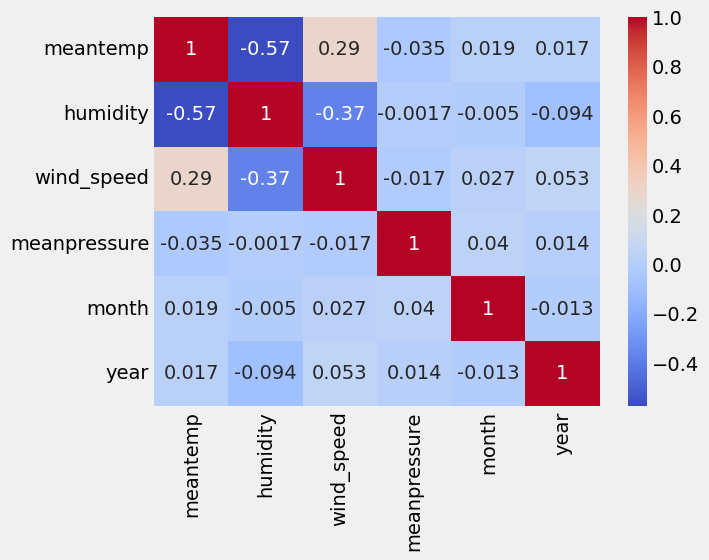

In [38]:
#Correlation of the variables
numeric_data = delhi_climate_data.select_dtypes(include = 'number')
corr_mat = numeric_data.corr()
import seaborn as sns
sns.heatmap(corr_mat, annot = True, cmap = 'coolwarm')

In [39]:
figure = px.scatter(delhi_climate_data, x="humidity",
                    y="meantemp", size="meantemp",
                    trendline="ols",
                    title = "Relationship Between Temperature and Humidity")
figure.show()

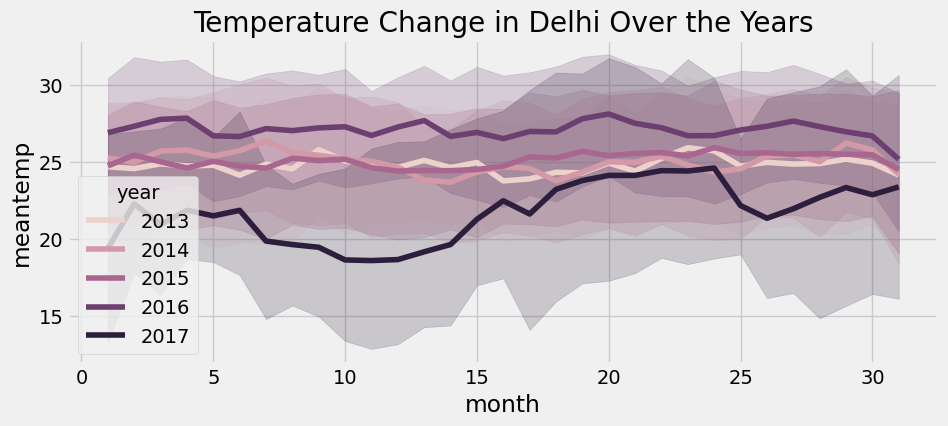

In [40]:
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.figure(figsize=(10, 4))
plt.title("Temperature Change in Delhi Over the Years")
sns.lineplot(delhi_climate_data, x='month', y='meantemp', hue='year')
plt.show()

In [41]:
#Split the dataset into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(delhi_climate_data,
                                   test_size = 0.2, random_state = 42)

In [42]:
X_train.shape

(1260, 6)

In [43]:
X_test.shape

(316, 6)

In [44]:
#Normalize the dat using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
min_max = MinMaxScaler()
X_train_scaled = min_max.fit_transform(X_train)
X_test_scaled = min_max.transform(X_test)

In [45]:
X_train_scaled[:10]

array([[0.68777293, 0.64191419, 0.06052918, 0.13110095, 0.13333333,
        0.        ],
       [0.8558952 , 0.3040429 , 0.30608916, 0.13141824, 0.3       ,
        0.75      ],
       [0.83487991, 0.3560231 , 0.07393983, 0.13165417, 0.06666667,
        0.75      ],
       [0.76215429, 0.2129813 , 0.41522291, 0.13150122, 0.1       ,
        1.        ],
       [0.70305677, 0.89315182, 0.02682131, 0.1304013 , 0.8       ,
        0.        ],
       [0.55225619, 0.52563256, 0.25071886, 0.13249917, 0.46666667,
        0.75      ],
       [0.79475983, 0.66801125, 0.29457801, 0.13048205, 0.3       ,
        0.75      ],
       [0.39737991, 0.42739274, 0.34588101, 0.13242355, 0.8       ,
        1.        ],
       [0.86735808, 0.13077558, 0.18811163, 0.13080807, 0.03333333,
        0.25      ],
       [0.3400655 , 0.51629538, 0.31569409, 0.13328127, 0.9       ,
        0.5       ]])

In [46]:
import numpy as np
length = 12
stride = 1

data_2 = []
targets = []

for i in range(0, len(X_train_scaled) - length + 1, stride):
    data_2.append(X_train_scaled[i:i+length])
    targets.append(X_train_scaled[i+length-1])

data_2 = np.array(data_2)
targets = np.array(targets)

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

In [48]:
n_features = X_train_scaled.shape[1]

In [49]:
climate_rnn_model = Sequential()
climate_rnn_model.add(SimpleRNN(120, activation = 'tanh', input_shape =(length,n_features)))
climate_rnn_model.add(Dropout(0.3))

climate_rnn_model.add(Dense(64, activation = 'tanh'))
climate_rnn_model.add(Dropout(0.3))

climate_rnn_model.add(Dense(32, activation = 'tanh'))
climate_rnn_model.add(Dropout(0.3))

#output layer
climate_rnn_model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [50]:
climate_rnn_model.compile(optimizer = 'adam', loss= 'mse', metrics= ['mse'])

In [51]:
history = climate_rnn_model.fit(data_2, targets, epochs = 50, batch_size = 16, validation_split = 0.2)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - loss: 0.4659 - mse: 0.4659 - val_loss: 0.0763 - val_mse: 0.0763
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1919 - mse: 0.1919 - val_loss: 0.0732 - val_mse: 0.0732
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1399 - mse: 0.1399 - val_loss: 0.0717 - val_mse: 0.0717
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1220 - mse: 0.1220 - val_loss: 0.0701 - val_mse: 0.0701
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1079 - mse: 0.1079 - val_loss: 0.0705 - val_mse: 0.0705
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0989 - mse: 0.0989 - val_loss: 0.0697 - val_mse: 0.0697
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0927 - mse: 0.0927 - val_loss: 0.0697 - val_mse: 0.0697
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0914 - mse: 0.0914 - val_loss: 0.0698 - val_mse: 0.0698
Epoch 9/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0874 

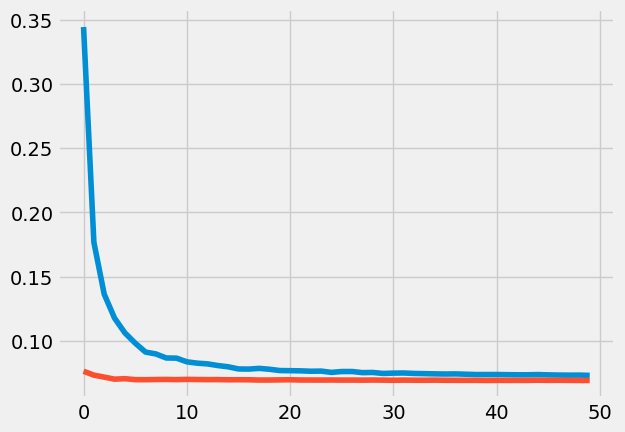

In [52]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.show()

In [56]:
import numpy as np
#Prepare X_test_scaled for prediction by creating sequences
#Using the same 'length' and ' stride' as for the training data
test_data_sequences=[]
for i in range(0, len(X_test_scaled)- length+1, stride):
  test_data_sequences.append(X_test_scaled[i:i+length])
test_data_sequences=np.array(test_data_sequences)

#Make Predictions
predictions_scaled=climate_rnn_model.predict(test_data_sequences)

#Inverse transform the predictions using the fitted MinMax Scaler
#Since the model predicts a single feature (Dense(1)), we need to create a dummy array
#with  the original number of feature to inverse transform correctly
#we assume that the model was implicitly trained to predict the first
dummy_array=np.zeros((predictions_scaled.shape[0], n_features))
dummy_array[:,0]= predictions_scaled.flatten()

predictions_inverse_tarnsformed = min_max.inverse_transform(dummy_array)

#Extract the inverse transformed predicted feature (e.g., 'meantemp')
predicted_feature = predictions_inverse_tarnsformed[:, 0]

#Display a sample of the inverse transformed predictions
print(predicted_feature[:10])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
[17.85014553 17.98590992 20.38038073 18.71319819 14.79850277 17.0976662
 19.45258964 18.09433736 18.54955477 23.75236958]
